In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, average_precision_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [ ]:


class FraudDetector:
    def __init__(self, contamination='auto', random_state=30):
        """
        Initialize fraud detection model using Isolation Forest.
        
        Parameters:
            contamination (float or 'auto'): Expected proportion of outliers
            random_state (int): Random seed for reproducibility
        """
        self.contamination = contamination
        self.random_state = random_state
        self.model = None
        self.feature_names = None
        self.threshold = None
        self._initialize_pipeline()

    def _initialize_pipeline(self):
        """Initialize the preprocessing and model pipeline."""
        numeric_features = [
            'amount', 'credit_score', 'transaction_velocity', 
            'amount_deviation', 'account_age_years',
            'avg_monthly_income', 'risk_score'
        ]
        
        categorical_features = [
            'transaction_type', 'location', 'time_of_day',
            'auth_method', 'age_group', 'home_location',
            'account_type', 'mobile_banking_user',
            'employment_status', 'international_activity'
        ]

        self.preprocessor = ColumnTransformer(transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])

        self.model = Pipeline([
            ('preprocessor', self.preprocessor),
            ('detector', IsolationForest(
                n_estimators=200,
                contamination=self.contamination,
                max_features=1.0,
                random_state=self.random_state,
                verbose=1
            ))
        ])

    def engineer_features(self, df):
        """
        Engineer features from raw transaction data.
        
        Parameters:
            df (pd.DataFrame): Input transaction data
            
        Returns:
            pd.DataFrame: Data with engineered features
        """
        df = df.copy()
        
        # Convert to datetime if not already
        if 'transaction_date' in df.columns:
            df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
            df['hour_of_day'] = df['transaction_date'].dt.hour
            df['day_of_week'] = df['transaction_date'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
        
        # Calculate time since last transaction per customer
        if 'customer_id' in df.columns and 'transaction_date' in df.columns:
            df = df.sort_values(['customer_id', 'transaction_date'])
            df['time_since_last_txn'] = df.groupby('customer_id')['transaction_date'].diff().dt.total_seconds() / 3600
            df['time_since_last_txn'] = df['time_since_last_txn'].fillna(0)
        
        # Fill missing values
        numeric_cols = df.select_dtypes(include=np.number).columns
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
        
        return df

    def fit(self, df):
        """
        Fit the fraud detection model.
        
        Parameters:
            df (pd.DataFrame): Training data containing features
        """
        df = self.engineer_features(df.copy())
        self.model.fit(df)
        
        # Calculate anomaly scores and threshold
        scores = self.model.named_steps['detector'].score_samples(
            self.model.named_steps['preprocessor'].transform(df)
        )
        self.threshold = np.percentile(scores, 100 * float(self.contamination))
        
        # Store feature names
        num_features = self.preprocessor.transformers_[0][2]
        cat_features = self.preprocessor.named_transformers_['cat'].get_feature_names_out(
            input_features=self.preprocessor.transformers_[1][2]
        )
        self.feature_names = np.concatenate([num_features, cat_features])
        
        return self

    def predict(self, df):
        """
        Predict fraud probabilities for new data.
        
        Parameters:
            df (pd.DataFrame): Data to score
            
        Returns:
            pd.DataFrame: Original data with added 'anomaly_score' and 'is_predicted_fraud' columns
        """
        if not self.model:
            raise RuntimeError("Model not trained. Call fit() first.")
            
        df = self.engineer_features(df.copy())
        transformed = self.model.named_steps['preprocessor'].transform(df)
        df['anomaly_score'] = self.model.named_steps['detector'].score_samples(transformed)
        df['is_predicted_fraud'] = (df['anomaly_score'] < self.threshold).astype(int)
        return df

    def evaluate(self, df):
        """
        Evaluate model performance against labeled data.
        
        Parameters:
            df (pd.DataFrame): Data containing both features and 'is_suspicious' column
        """
        if "is_suspicious" not in df.columns:
            raise ValueError("Data needs an 'is_suspicious' column for evaluation.")

        preds = self.predict(df)
        
        print("\nClassification Report:")
        print(classification_report(preds['is_suspicious'], preds['is_predicted_fraud'], target_names=['Legitimate', 'Fraud']))
        
        print(f"\nAUROC: {roc_auc_score(preds['is_suspicious'], -preds['anomaly_score']):.4f}")
        print(f"Average Precision: {average_precision_score(preds['is_suspicious'], -preds['anomaly_score']):.4f}")
        
        plt.figure(figsize=(10, 6))
        cm = confusion_matrix(preds['is_suspicious'], preds['is_predicted_fraud'])
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", 
                   xticklabels=['Legitimate', 'Fraud'],
                   yticklabels=['Legitimate', 'Fraud'])
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
        
        # Plot score distributions
        plt.figure(figsize=(10, 6))
        for label in [0, 1]:
            sns.kdeplot(preds.loc[preds['is_suspicious'] == label, 'anomaly_score'], 
                       label='Fraud' if label else 'Legitimate')
        plt.axvline(self.threshold, color='r', linestyle='--', label='Threshold')
        plt.title("Anomaly Score Distribution by Class")
        plt.xlabel("Anomaly Score")
        plt.ylabel("Density")
        plt.legend()
        plt.show()

    def feature_importance(self):
        """Plot feature importance based on the Isolation Forest model."""
        if not hasattr(self.model.named_steps['detector'], 'feature_importances_'):
            print("Feature importance is not available for this model.")
            return

        importances = self.model.named_steps['detector'].feature_importances_
        importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(12, 8))
        sns.barplot(x='importance', y='feature', data=importance_df.head(20))
        plt.title("Top 20 Fraud Detection Features by Importance")
        plt.tight_layout()
        plt.show()

    def save(self, path):
        """Save model to disk."""
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump({
            "model": self.model,
            "threshold": self.threshold,
            "features": self.feature_names,
            "contamination": self.contamination,
            "random_state": self.random_state
        }, path)

    @classmethod
    def load(cls, path):
        """Load model from disk."""
        data = joblib.load(path)
        detector = cls(
            contamination=data['contamination'],
            random_state=data['random_state']
        )
        detector.model = data['model']
        detector.threshold = data['threshold']
        detector.feature_names = data['features']
        return detector

In [ ]:
# if __name__ == "__main__":
#     dfu = pd.read_csv("global_ime_bank_customers.csv")
#     for customer_id in dfu["customer_id"].unique():
#         print("Generating transaction data")
#         transactions = pd.read_csv(f"segmented_transactions/user_{customer_id}_transactions.csv")
#         if len(transactions) > 85:
#             transactions = transactions.sort_values(by="transaction_date").head(85)
#         if "is_suspicious" in transactions.columns:
#             transactions = transactions.drop(columns=["is_suspicious"])
#         detector = FraudDetector(contamination=0.06531)
#         print("Training fraud detection model...")


#         # Train the model on the entire dataset
#         detector.fit(transactions)

#         detector.save(f'models/fraud_detector{customer_id}.joblib')
#         print("Model saved successfully")


Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.82      1.00      0.90        32
       Fraud       1.00      0.36      0.53        11

    accuracy                           0.84        43
   macro avg       0.91      0.68      0.72        43
weighted avg       0.87      0.84      0.81        43


AUROC: 0.9148
Average Precision: 0.8208


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s


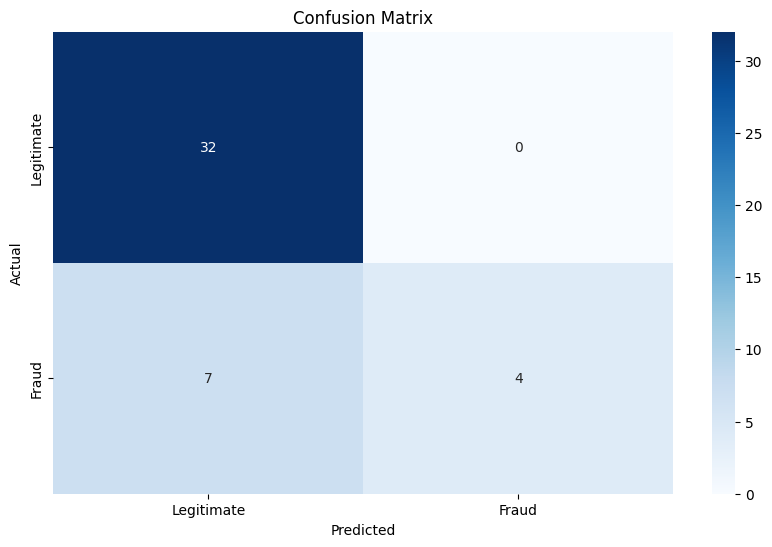

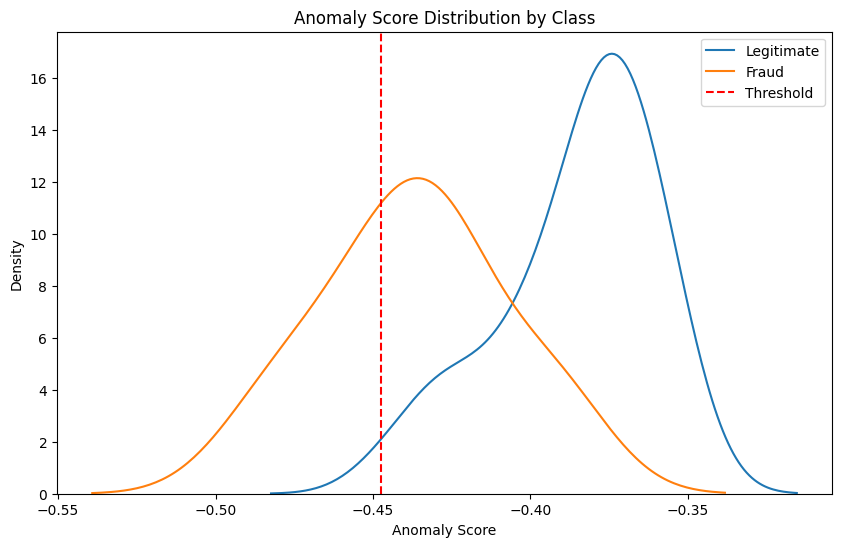

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = FraudDetector.load(f"models/fraud_detectorGIME000001.joblib")
transactions = pd.read_csv(f"/Users/dipeshacharya/Desktop/hackathon/gbime_fraud_detection/data preprocessing/test.csv")
model.evaluate(transactions)
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)
# model.evaluate()
# print(f"Accuracy: {accuracy:.2f}")
# print(f"Precision: {precision:.2f}")
# print(f"Recall: {recall:.2f}")
# print(f"F1 Score: {f1:.2f}")